# Bates-Calibrated SPY Extension

This notebook builds a **Bates model** extension (Heston + jumps) on top of the Table 2 workflow:

1. Pull real SPY option quotes,
2. calibrate Bates parameters to market call mids across maturities,
3. simulate Bates Monte Carlo paths,
4. compare hedging performance of:
   - Black-Scholes delta benchmark,
   - Classical LSTM,
   - Augmented LSTM.

This keeps the paper-style simulation/training structure while using market-informed dynamics with jump risk.

In [9]:
import os, sys, json, math
from dataclasses import dataclass
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

try:
    import yfinance as yf
except Exception:
    yf = None

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.experiment import Config, run_experiment, report_table
from src.architectures import ClassicalLSTM, AugmentedLSTM
from src.payoffs import call_payoff
from src.simulators import compute_norm_stats

# Bates/BS helpers extracted from this notebook
from src.bates import (
    simulate_bates_paths_torch,
    simulate_bates_terminal_multipliers,
    bates_call_prices_mc,
    bates_call_price_mc,
    bs_call_price,
    bs_delta_np,
    bates_delta_mc_fd_vec_spots,
    apply_friction_to_deltas,
)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
np.random.seed(42)
torch.manual_seed(42)
print('Device:', DEVICE)
print('yfinance available:', yf is not None)

Device: cpu
yfinance available: True


## 1) Market snapshot and calibration basket

Loaded cached option snapshot: c:\Users\Michael\Code\ML-for-Finance\data\option_snapshots\spy_otm_snapshot_2026-03-19_k575_725_m7_s30_quotes.csv
[Info] hedge_expiry=2026-04-20 has no quotes; fallback to 2026-06-30.
Valuation date (shifted): 2026-03-19
Option snapshot date used: 2026-03-19
Spot at valuation date=659.80
Option mids source: contract historical Close on common snapshot date (missing contracts dropped)
Min expiry spacing days: 30
Strike filter: [575, 725]
Calibration expiries: ['2026-04-20', '2026-05-22', '2026-06-30', '2026-07-31', '2026-08-31', '2026-09-30', '2026-12-18']
Hedge expiry=2026-06-30, T_HEDGE=0.2822 years
Calibration quotes: 231 total

Options availability per expiry (all valid vs all OTM selected)


,expiry,calls_valid,calls_otm,puts_valid,puts_otm,selected_calls,selected_puts,selected_total
0,2026-04-20,78,46,106,65,0,0,0
1,2026-05-22,79,46,97,61,0,0,0
2,2026-06-30,151,66,129,85,14,39,53
3,2026-07-31,112,64,110,49,36,24,60
4,2026-08-31,106,62,99,50,18,19,37
5,2026-09-30,108,39,109,70,21,29,50
6,2026-12-18,31,14,31,17,14,17,31


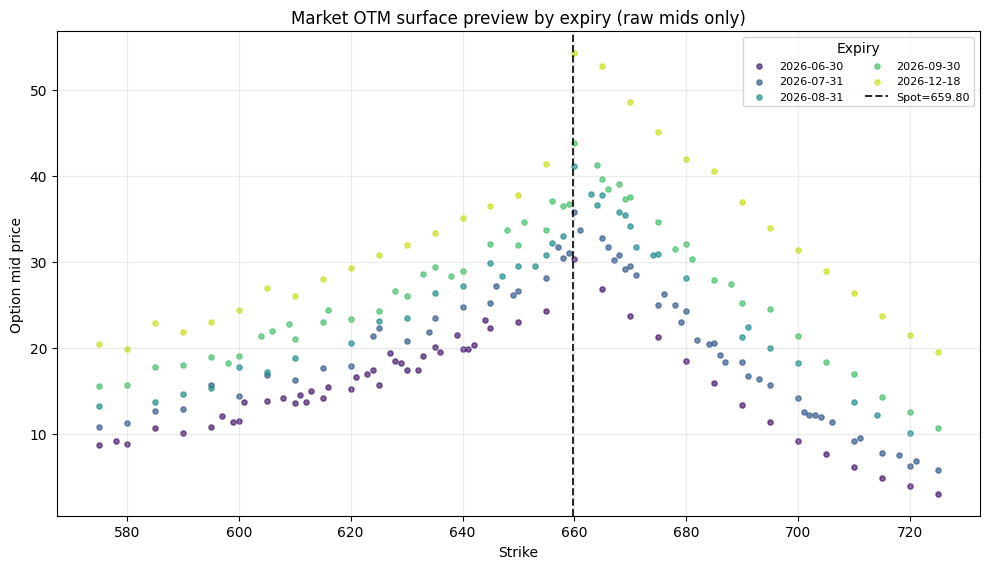

In [10]:
if yf is None:
    raise RuntimeError('yfinance is required. Install with: uv sync --extra notebook')

# Stable snapshot configuration + persistent cache.
max_expiries = 7
min_expiry_spacing_days = 30
strikes_per_expiry = None  # None -> keep all OTM strikes in range per expiry
strike_min = 575.0
strike_max = 725.0
FIXED_VALUATION_DATE = '2026-03-19'  # keeps runs reproducible
USE_CACHED_SNAPSHOT_IF_AVAILABLE = True
FORCE_REFRESH_SNAPSHOT = False

DATA_DIR = os.path.join(ROOT, 'data', 'option_snapshots')
os.makedirs(DATA_DIR, exist_ok=True)
cache_tag = f"spy_otm_snapshot_{FIXED_VALUATION_DATE}_k{int(strike_min)}_{int(strike_max)}_m{max_expiries}_s{min_expiry_spacing_days}"
cache_quotes_path = os.path.join(DATA_DIR, cache_tag + '_quotes.csv')
cache_meta_path = os.path.join(DATA_DIR, cache_tag + '_meta.json')
cache_availability_path = os.path.join(DATA_DIR, cache_tag + '_availability.csv')

if USE_CACHED_SNAPSHOT_IF_AVAILABLE and (not FORCE_REFRESH_SNAPSHOT) and os.path.exists(cache_quotes_path) and os.path.exists(cache_meta_path):
    quotes = pd.read_csv(cache_quotes_path)
    with open(cache_meta_path, 'r', encoding='utf-8') as f:
        meta = json.load(f)
    spot = float(meta['spot'])
    selected_expiries = list(meta['selected_expiries'])
    hedge_expiry = str(meta['hedge_expiry'])
    T_HEDGE = float(meta['T_HEDGE'])
    now = datetime.fromisoformat(meta['valuation_datetime_utc'])
    snapshot_date = pd.Timestamp(meta['snapshot_date']).tz_localize(None)
    availability_df = pd.read_csv(cache_availability_path) if os.path.exists(cache_availability_path) else pd.DataFrame()
    print('Loaded cached option snapshot:', cache_quotes_path)
else:
    tk = yf.Ticker('SPY')
    now = pd.Timestamp(FIXED_VALUATION_DATE).tz_localize('UTC').to_pydatetime()
    hist_3m = tk.history(period='3mo', interval='1d', auto_adjust=False)['Close'].dropna()
    hist_3m.index = pd.to_datetime(hist_3m.index).tz_localize(None)
    snapshot_date = pd.Timestamp(FIXED_VALUATION_DATE).tz_localize(None)
    hist_ref = hist_3m.loc[hist_3m.index <= snapshot_date]
    if hist_ref.empty:
        raise RuntimeError('Could not find historical SPY close up to fixed valuation date.')
    snapshot_date = hist_ref.index[-1]
    spot = float(hist_ref.iloc[-1])

    expiries = list(tk.options)
    if not expiries:
        raise RuntimeError('No SPY expiries returned by yfinance.')

    selected_expiries = []
    last_selected_dt = None
    for e in expiries:
        dt = datetime.fromisoformat(e).replace(tzinfo=timezone.utc)
        if (dt - now).days < 14:
            continue
        if (last_selected_dt is not None) and ((dt - last_selected_dt).days < min_expiry_spacing_days):
            continue
        selected_expiries.append(e)
        last_selected_dt = dt
        if len(selected_expiries) >= max_expiries:
            break
    if not selected_expiries:
        raise RuntimeError('No suitable expiries >=14 days found.')

    hedge_expiry = selected_expiries[0]
    hedge_expiry_dt = datetime.fromisoformat(hedge_expiry).replace(tzinfo=timezone.utc)
    T_HEDGE = max((hedge_expiry_dt - now).total_seconds() / (365.0 * 24 * 3600), 1 / 365)

    hist_close_cache = {}

    def get_contract_mid_at_ref(contract_symbol, snap_date_naive):
        if contract_symbol in hist_close_cache:
            return hist_close_cache[contract_symbol]
        try:
            h = yf.Ticker(contract_symbol).history(period='6mo', interval='1d', auto_adjust=False)[['Close']].copy()
        except Exception:
            hist_close_cache[contract_symbol] = np.nan
            return np.nan
        if h.empty:
            hist_close_cache[contract_symbol] = np.nan
            return np.nan
        h.index = pd.to_datetime(h.index).tz_localize(None)
        if snap_date_naive not in h.index:
            hist_close_cache[contract_symbol] = np.nan
            return np.nan
        mid_val = float(h.loc[snap_date_naive, 'Close'])
        hist_close_cache[contract_symbol] = mid_val
        return mid_val

    quote_rows = []
    availability_rows = []
    for e in selected_expiries:
        dt = datetime.fromisoformat(e).replace(tzinfo=timezone.utc)
        tau = max((dt - now).total_seconds() / (365.0 * 24 * 3600), 1 / 365)

        chain = tk.option_chain(e)
        calls = chain.calls.copy()
        puts = chain.puts.copy()

        calls = calls[(calls['strike'] > 0)].copy()
        puts = puts[(puts['strike'] > 0)].copy()
        calls = calls[(calls['strike'] >= strike_min) & (calls['strike'] <= strike_max)].copy()
        puts = puts[(puts['strike'] >= strike_min) & (puts['strike'] <= strike_max)].copy()

        n_calls_valid = int(len(calls))
        n_puts_valid = int(len(puts))

        calls = calls[calls['strike'] > spot].copy()
        puts = puts[puts['strike'] < spot].copy()

        n_calls_otm = int(len(calls))
        n_puts_otm = int(len(puts))

        if not calls.empty:
            calls = calls.sort_values(['strike']).copy()
            if strikes_per_expiry is not None:
                calls = calls.iloc[:int(strikes_per_expiry)].copy()
            calls['mid'] = calls['contractSymbol'].apply(lambda s: get_contract_mid_at_ref(s, snapshot_date))
            calls = calls[np.isfinite(calls['mid']) & (calls['mid'] > 0)].copy()
            calls['spread'] = np.maximum(0.02 * calls['mid'], 0.05)
            calls['bid'] = np.maximum(calls['mid'] - 0.5 * calls['spread'], 1e-6)
            calls['ask'] = calls['mid'] + 0.5 * calls['spread']
            calls['option_type'] = 'call'

        if not puts.empty:
            puts = puts.sort_values(['strike']).copy()
            if strikes_per_expiry is not None:
                puts = puts.iloc[:int(strikes_per_expiry)].copy()
            puts['mid'] = puts['contractSymbol'].apply(lambda s: get_contract_mid_at_ref(s, snapshot_date))
            puts = puts[np.isfinite(puts['mid']) & (puts['mid'] > 0)].copy()
            puts['spread'] = np.maximum(0.02 * puts['mid'], 0.05)
            puts['bid'] = np.maximum(puts['mid'] - 0.5 * puts['spread'], 1e-6)
            puts['ask'] = puts['mid'] + 0.5 * puts['spread']
            puts['option_type'] = 'put'

        selected = pd.concat([calls, puts], ignore_index=True)
        availability_rows.append({
            'expiry': e,
            'calls_valid': n_calls_valid,
            'calls_otm': n_calls_otm,
            'puts_valid': n_puts_valid,
            'puts_otm': n_puts_otm,
            'selected_calls': int(len(calls)),
            'selected_puts': int(len(puts)),
            'selected_total': int(len(selected)),
        })

        if not selected.empty:
            selected['expiry'] = e
            selected['tau'] = tau
            quote_rows.append(selected[['expiry', 'tau', 'option_type', 'strike', 'bid', 'ask', 'mid', 'spread']])

    if not quote_rows:
        raise RuntimeError('Failed to build multi-maturity calibration basket.')

    quotes = pd.concat(quote_rows, ignore_index=True)
    quotes = quotes.sort_values(['tau', 'strike', 'option_type']).reset_index(drop=True)
    availability_df = pd.DataFrame(availability_rows)

    # Persist snapshot for deterministic future runs.
    quotes.to_csv(cache_quotes_path, index=False)
    availability_df.to_csv(cache_availability_path, index=False)
    meta = {
        'valuation_datetime_utc': pd.Timestamp(now).isoformat(),
        'snapshot_date': str(pd.Timestamp(snapshot_date).date()),
        'spot': float(spot),
        'selected_expiries': selected_expiries,
        'hedge_expiry': hedge_expiry,
        'T_HEDGE': float(T_HEDGE),
        'max_expiries': int(max_expiries),
        'min_expiry_spacing_days': int(min_expiry_spacing_days),
        'strike_min': float(strike_min),
        'strike_max': float(strike_max),
        'strikes_per_expiry': None if strikes_per_expiry is None else int(strikes_per_expiry),
    }
    with open(cache_meta_path, 'w', encoding='utf-8') as f:
        json.dump(meta, f, indent=2)
    print('Saved option snapshot cache:', cache_quotes_path)

# ensure availability_df exists if loaded from cache without availability file
if 'availability_df' not in locals():
    availability_df = pd.DataFrame()

# Normalize expiry strings (cached CSV may parse as datetime) so hedge_expiry joins work reliably.
quotes['expiry'] = pd.to_datetime(quotes['expiry'], errors='coerce').dt.strftime('%Y-%m-%d')
hedge_expiry = pd.Timestamp(str(hedge_expiry)).strftime('%Y-%m-%d')
selected_expiries = [pd.Timestamp(str(x)).strftime('%Y-%m-%d') for x in selected_expiries]
available_expiries = sorted(pd.Series(quotes['expiry']).dropna().unique().tolist())
if hedge_expiry not in available_expiries:
    if not available_expiries:
        raise RuntimeError('No expiries available in quotes after normalization/filtering.')
    old_hedge_expiry = hedge_expiry
    hedge_expiry = available_expiries[0]
    hedge_expiry_dt = datetime.fromisoformat(hedge_expiry).replace(tzinfo=timezone.utc)
    T_HEDGE = max((hedge_expiry_dt - now).total_seconds() / (365.0 * 24 * 3600), 1 / 365)
    print(f'[Info] hedge_expiry={old_hedge_expiry} has no quotes; fallback to {hedge_expiry}.')

# Hard sanity checks: ensure basket truly contains only OTM puts/calls relative to spot.
bad_calls = quotes[(quotes['option_type'] == 'call') & (quotes['strike'] <= spot)]
bad_puts = quotes[(quotes['option_type'] == 'put') & (quotes['strike'] >= spot)]
if (len(bad_calls) > 0) or (len(bad_puts) > 0):
    raise RuntimeError(f'OTM filter violated: bad_calls={len(bad_calls)}, bad_puts={len(bad_puts)}')
# For put rows, convert observed put mids to call-equivalent prices via put-call parity (r=0).
quotes['target_price'] = np.where(
    quotes['option_type'].eq('call'),
    quotes['mid'],
    quotes['mid'] + spot - quotes['strike'],
)
quotes['weight'] = 1.0 / np.maximum(quotes['spread'], 0.05)
quotes['weight'] = quotes['weight'] / quotes['weight'].mean()

print(f'Valuation date (shifted): {pd.Timestamp(now).date()}')
print(f'Option snapshot date used: {pd.Timestamp(snapshot_date).date()}')
print(f'Spot at valuation date={spot:.2f}')
print('Option mids source: contract historical Close on common snapshot date (missing contracts dropped)')
print(f'Min expiry spacing days: {min_expiry_spacing_days}')
print(f'Strike filter: [{strike_min:.0f}, {strike_max:.0f}]')
print(f'Calibration expiries: {selected_expiries}')
print(f'Hedge expiry={hedge_expiry}, T_HEDGE={T_HEDGE:.4f} years')
print(f'Calibration quotes: {len(quotes)} total')
print('\nOptions availability per expiry (all valid vs all OTM selected)')
display(availability_df)

# Market-only OTM sanity plot before any expensive calibration (show all maturities).
fig, ax = plt.subplots(1, 1, figsize=(10, 5.8))
uniq_exp = list(quotes['expiry'].drop_duplicates())
colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(uniq_exp)))
for c, exp_i in zip(colors, uniq_exp):
    g_put = quotes[(quotes['expiry'] == exp_i) & (quotes['option_type'] == 'put')].sort_values('strike')
    g_call = quotes[(quotes['expiry'] == exp_i) & (quotes['option_type'] == 'call')].sort_values('strike')
    if len(g_put) > 0:
        ax.scatter(g_put['strike'], g_put['mid'], s=14, alpha=0.70, color=c)
    if len(g_call) > 0:
        ax.scatter(g_call['strike'], g_call['mid'], s=14, alpha=0.70, color=c, label=exp_i)
ax.axvline(spot, color='black', linestyle='--', linewidth=1.4, alpha=0.85, label=f'Spot={spot:.2f}')
ax.set_title('Market OTM surface preview by expiry (raw mids only)')
ax.set_xlabel('Strike')
ax.set_ylabel('Option mid price')
ax.grid(alpha=0.25)
ax.legend(fontsize=8, ncol=2, loc='best', title='Expiry')
plt.tight_layout()
plt.show()

Points plotted: 231
IV range: [0.1475, 0.2791]


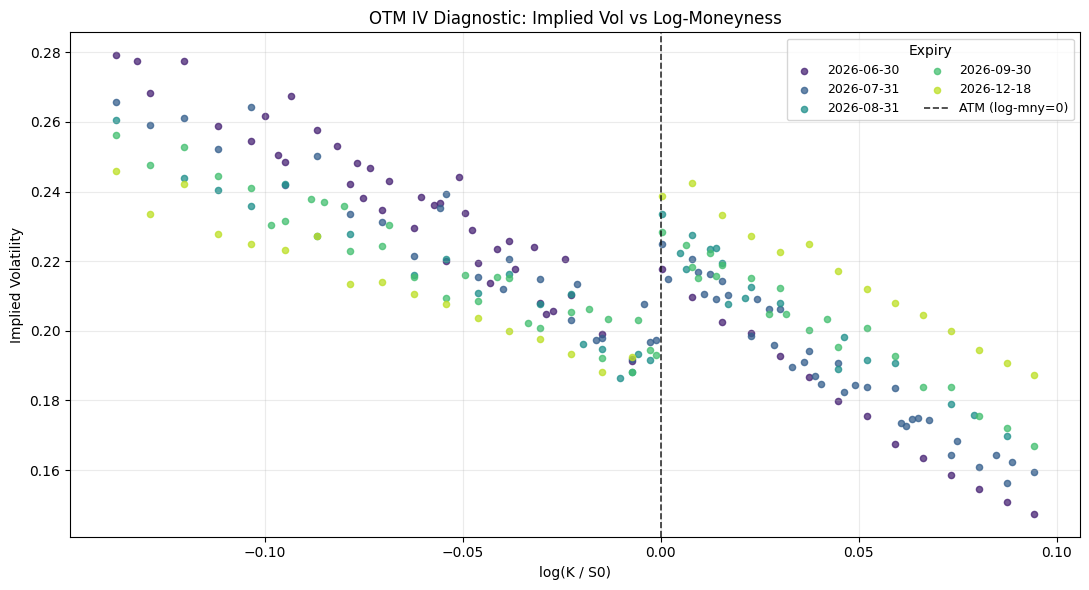

In [11]:
# IV diagnostic on the same OTM basket: IV vs log-moneyness (cleaner than price-space)
# Assumes these variables already exist from your notebook:
# quotes (with columns: strike, tau, option_type, mid, target_price), spot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

def _bs_call_price(S, K, T, r, sigma):
    if T <= 0:
        return max(S - K, 0.0)
    sigma = max(float(sigma), 1e-12)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def _implied_vol_call(price, S, K, T, r=0.0):
    # Robust IV from call-equivalent price
    intrinsic = max(S - K * np.exp(-r * T), 0.0)
    upper = S
    p = float(price)
    if not np.isfinite(p) or p <= intrinsic + 1e-10 or p >= upper - 1e-10:
        return np.nan

    f = lambda sig: _bs_call_price(S, K, T, r, sig) - p
    try:
        return brentq(f, 1e-6, 5.0, maxiter=200)
    except Exception:
        return np.nan

# Build plotting frame
iv_df = quotes.copy()
iv_df["call_equiv_price"] = np.where(
    iv_df["option_type"].eq("call"),
    iv_df["mid"],
    iv_df["mid"] + spot - iv_df["strike"]  # put-call parity -> call-equivalent
)
iv_df["log_mny"] = np.log(iv_df["strike"] / spot)

iv_df["iv"] = [
    _implied_vol_call(p, spot, k, t, r=0.0)
    for p, k, t in zip(iv_df["call_equiv_price"], iv_df["strike"], iv_df["tau"])
]

# keep valid points
iv_df = iv_df[np.isfinite(iv_df["iv"]) & (iv_df["iv"] > 0)].copy()

# Plot
fig, ax = plt.subplots(figsize=(11, 6))
expiries = sorted(iv_df["expiry"].unique())
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(expiries)))

for c, e in zip(cmap, expiries):
    d = iv_df[iv_df["expiry"] == e].sort_values("log_mny")
    ax.scatter(d["log_mny"], d["iv"], s=20, alpha=0.75, color=c, label=e)

ax.axvline(0.0, color="k", ls="--", lw=1.2, alpha=0.8, label="ATM (log-mny=0)")
ax.set_title("OTM IV Diagnostic: Implied Vol vs Log-Moneyness")
ax.set_xlabel("log(K / S0)")
ax.set_ylabel("Implied Volatility")
ax.grid(alpha=0.25)
ax.legend(title="Expiry", ncol=2, fontsize=9)
plt.tight_layout()

print(f"Points plotted: {len(iv_df)}")
print(f"IV range: [{iv_df['iv'].min():.4f}, {iv_df['iv'].max():.4f}]")

## 2) Bates Monte Carlo pricer and calibration

We calibrate parameters `(kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ)` by minimizing weighted option-price MSE across maturities (put quotes are converted to call-equivalent targets via put-call parity).

In [12]:
RUN_HEAVY_CALIBRATION = True  # set True after checking market-only surface preview
if not RUN_HEAVY_CALIBRATION:
    raise RuntimeError('Calibration is disabled. Inspect market surface first, then set RUN_HEAVY_CALIBRATION=True in this cell.')

# Bates MC pricer helpers are imported from src.bates now:
# - simulate_bates_terminal_multipliers
# - bates_call_prices_mc
# (keeps the notebook shorter and the logic shared across sections)


def bates_surface_prices_mc(quotes_df, params, n_steps=40, n_paths=12000, seed=123):
    out = np.zeros(len(quotes_df), dtype=float)
    for i, (tau, g) in enumerate(quotes_df.groupby('tau', sort=True)):
        K_arr = g['strike'].to_numpy(dtype=float)
        model = bates_call_prices_mc(
            S0=spot,
            K_array=K_arr,
            T=float(tau),
            params=params,
            n_steps=max(6, int(round(n_steps * float(tau) / max(T_HEDGE, 1e-6)))),
            n_paths=n_paths,
            seed=seed + i,
        )
        out[g.index.to_numpy()] = model
    return out


def calib_objective(x):
    kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ = x
    if theta <= 0 or xi <= 0 or v0 <= 0 or kappa <= 0 or abs(rho) >= 0.999:
        return 1e9
    if lambdaJ < 0 or sigmaJ <= 0:
        return 1e9

    feller_pen = max(0.0, xi * xi - 2.0 * kappa * theta)

    model = bates_surface_prices_mc(
        quotes_df=quotes,
        params=x,
        n_steps=40,
        n_paths=7000,
        seed=777,
    )
    y = quotes['target_price'].to_numpy(dtype=float)
    w = quotes['weight'].to_numpy(dtype=float)
    err = w * (model - y) ** 2
    return float(err.mean() + 10.0 * feller_pen)


bounds = [
    (0.2, 8.0),      # kappa
    (0.005, 0.20),   # theta
    (0.05, 1.20),    # xi
    (-0.95, -0.05),  # rho
    (0.005, 0.25),   # v0
    (0.0, 8.0),      # lambdaJ
    (-0.20, 0.05),   # muJ (downward jumps usually negative)
    (0.02, 0.60),    # sigmaJ
]

USE_SAVED_CALIBRATED_PARAMS = True
SAVE_CALIBRATED_PARAMS = True
PARAMS_PATH = os.path.abspath(os.path.join(ROOT, 'results_bates', 'bates_calibrated_params.json'))
os.makedirs(os.path.dirname(PARAMS_PATH), exist_ok=True)
calibration_objective = float('nan')

if USE_SAVED_CALIBRATED_PARAMS and os.path.isfile(PARAMS_PATH):
    with open(PARAMS_PATH, 'r', encoding='utf-8') as f:
        p = json.load(f)
    kappa = float(p['kappa']); theta = float(p['theta']); xi = float(p['xi']); rho = float(p['rho'])
    v0 = float(p['v0']); lambdaJ = float(p['lambdaJ']); muJ = float(p['muJ']); sigmaJ = float(p['sigmaJ'])
    calibration_objective = float(p.get('objective', float('nan')))
    print('Loaded calibrated Bates params from:', PARAMS_PATH)
    print('(Set USE_SAVED_CALIBRATED_PARAMS=False to re-run differential_evolution.)')
else:
    print('Running multi-maturity Bates calibration (this can take a few minutes)...')
    res = differential_evolution(
        calib_objective,
        bounds=bounds,
        maxiter=40,
        popsize=12,
        seed=42,
        polish=False,
        disp=True,
    )
    kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ = [float(v) for v in res.x]
    calibration_objective = float(res.fun)
    if SAVE_CALIBRATED_PARAMS:
        payload = {
            'kappa': kappa, 'theta': theta, 'xi': xi, 'rho': rho, 'v0': v0,
            'lambdaJ': lambdaJ, 'muJ': muJ, 'sigmaJ': sigmaJ,
            'objective': calibration_objective,
            'timestamp_utc': datetime.now(timezone.utc).isoformat(),
        }
        with open(PARAMS_PATH, 'w', encoding='utf-8') as f:
            json.dump(payload, f, indent=2)
        print('Saved calibrated Bates params to:', PARAMS_PATH)

print('\nCalibrated params:')
print(f'kappa={kappa:.4f}, theta={theta:.4f}, xi={xi:.4f}, rho={rho:.4f}, v0={v0:.4f}')
print(f'lambdaJ={lambdaJ:.4f}, muJ={muJ:.4f}, sigmaJ={sigmaJ:.4f}')
print(f'Objective={calibration_objective:.6e}')

quotes = quotes.copy()
quotes['model_call_price'] = bates_surface_prices_mc(
    quotes_df=quotes,
    params=(kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ),
    n_steps=60,
    n_paths=24000,
    seed=2026,
)
quotes['model_price'] = np.where(
    quotes['option_type'].eq('call'),
    quotes['model_call_price'],
    quotes['model_call_price'] - spot + quotes['strike'],
)
fit_mse = float(np.mean((quotes['model_price'].to_numpy() - quotes['mid'].to_numpy()) ** 2))
print(f'Post-calibration surface MSE={fit_mse:.3e}')

Loaded calibrated Bates params from: c:\Users\Michael\Code\ML-for-Finance\results_bates\bates_calibrated_params.json
(Set USE_SAVED_CALIBRATED_PARAMS=False to re-run differential_evolution.)

Calibrated params:
kappa=5.4406, theta=0.0233, xi=0.1478, rho=-0.7692, v0=0.0280
lambdaJ=0.3273, muJ=-0.0524, sigmaJ=0.0491
Objective=4.230451e+00
Post-calibration surface MSE=7.320e+00


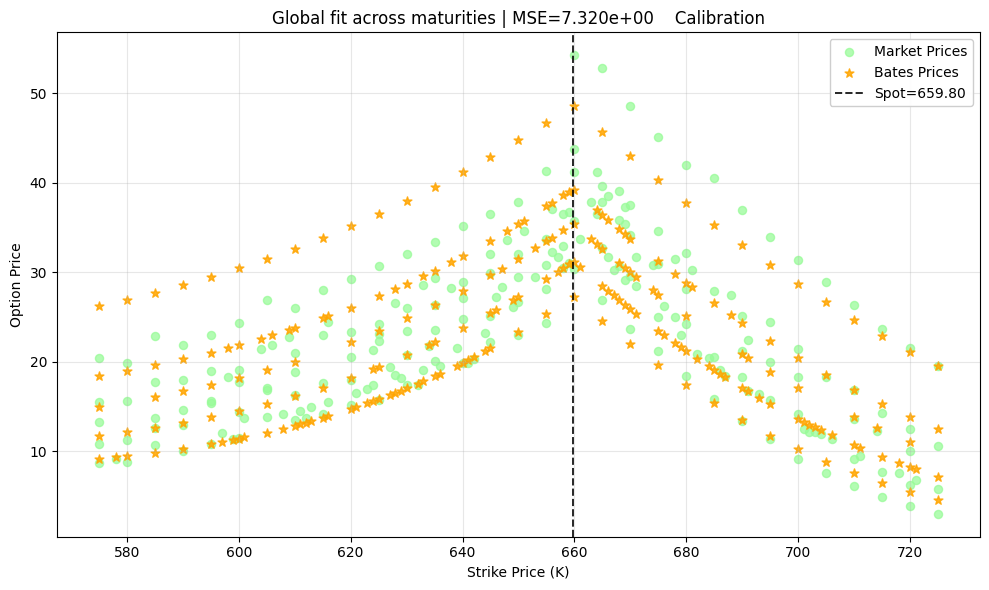

In [13]:
# Calibration scatter (raw option prices): one global view across all maturities.
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
plot_df = quotes.copy().sort_values(['expiry', 'strike', 'option_type'])

ax.scatter(
    plot_df['strike'],
    plot_df['mid'],
    s=34,
    color='palegreen',
    alpha=0.75,
    label='Market Prices',
)
ax.scatter(
    plot_df['strike'],
    plot_df['model_price'],
    s=44,
    marker='*',
    color='orange',
    alpha=0.85,
    label='Bates Prices',
)
ax.axvline(spot, color='black', linestyle='--', linewidth=1.4, alpha=0.85, label=f'Spot={spot:.2f}')

mse_global = float(np.mean((plot_df['model_price'] - plot_df['mid']) ** 2))
ax.set_title(f'Global fit across maturities | MSE={mse_global:.3e}    Calibration')
ax.set_xlabel('Strike Price (K)')
ax.set_ylabel('Option Price')
ax.grid(alpha=0.30)
ax.legend(loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.show()

## 2b) Implied-vol surface view: market BS IV vs Bates-fitted IV

Blue dots = market-implied vols (from option mids via BS inversion).  
Orange crosses = implied vols of Bates-fitted model prices.

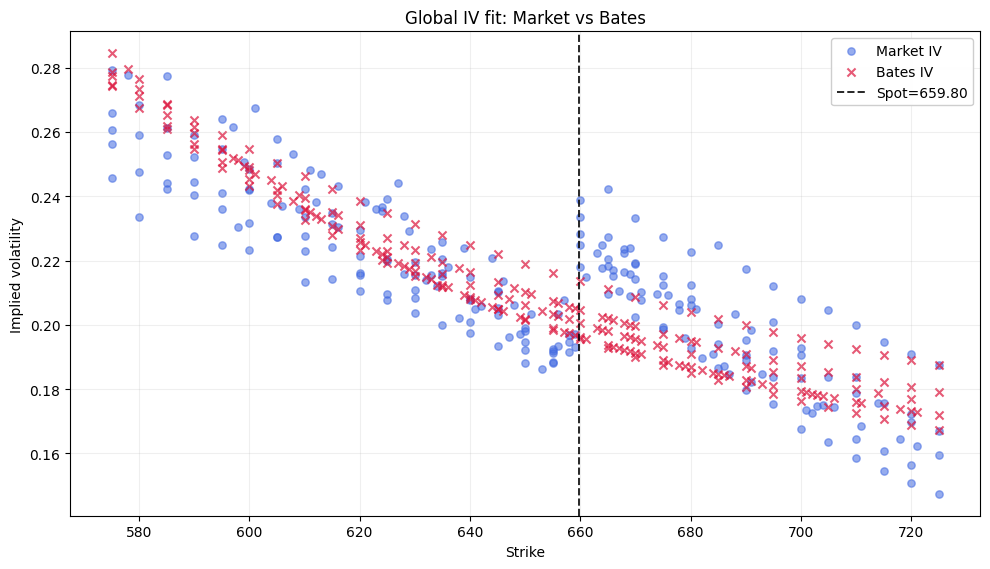

In [14]:
def bs_call_price_r(S, K, T, sigma, r=0.0):
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0)
    d1 = (math.log(S / K) + (r + 0.5 * sigma * sigma) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    cdf = lambda x: 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))
    return S * cdf(d1) - K * math.exp(-r * T) * cdf(d2)


def implied_vol_from_call(price, S, K, T, r=0.0):
    intrinsic = max(S - K * math.exp(-r * T), 0.0)
    # Clamp tiny numerical violations from MC noise.
    p = min(max(float(price), intrinsic + 1e-10), S)

    lo, hi = 1e-4, 5.0
    for _ in range(100):
        mid = 0.5 * (lo + hi)
        pmid = bs_call_price_r(S, K, T, mid, r=r)
        if pmid > p:
            hi = mid
        else:
            lo = mid
    return 0.5 * (lo + hi)


iv_df = quotes.copy()
iv_df['market_call_equiv'] = np.where(
    iv_df['option_type'].eq('call'),
    iv_df['mid'],
    iv_df['mid'] + spot - iv_df['strike'],
)
iv_df['iv_market'] = [implied_vol_from_call(p, spot, k, t) for p, k, t in zip(iv_df['market_call_equiv'], iv_df['strike'], iv_df['tau'])]
iv_df['iv_bates'] = [implied_vol_from_call(p, spot, k, t) for p, k, t in zip(iv_df['model_call_price'], iv_df['strike'], iv_df['tau'])]

# Single global plot across maturities:
# Cleaner global IV plot: only market vs Bates (no expiry color split)
fig, ax = plt.subplots(1, 1, figsize=(10, 5.8))

# Optional zoom window around spot
zoom_lo = 0.85 * spot
zoom_hi = 1.15 * spot
g = iv_df[(iv_df["strike"] >= zoom_lo) & (iv_df["strike"] <= zoom_hi)].copy()

# If you want full range, just use: g = iv_df.copy()

ax.scatter(
    g["strike"], g["iv_market"],
    marker="o", s=28, alpha=0.55, color="royalblue",
    label="Market IV"
)
ax.scatter(
    g["strike"], g["iv_bates"],
    marker="x", s=34, alpha=0.70, color="crimson",
    label="Bates IV"
)

ax.axvline(spot, color="black", linestyle="--", linewidth=1.4, alpha=0.85, label=f"Spot={spot:.2f}")
ax.set_title("Global IV fit: Market vs Bates")
ax.set_xlabel("Strike")
ax.set_ylabel("Implied volatility")
ax.grid(alpha=0.2)
ax.legend(loc="best", framealpha=0.95)
plt.tight_layout()
plt.show()

## 3) Simulate calibrated Bates paths for hedging experiments

In [15]:
# Bates torch path simulation imported from src.bates:
# simulate_bates_paths_torch

A2A_FIXED_N = True
A2A_N = 90  # paper-style fixed hedging grid for apples-to-apples comparisons
N_HEDGE_TARGET = 40
N_HEDGE = int(A2A_N) if A2A_FIXED_N else max(int(round(T_HEDGE * 365)), N_HEDGE_TARGET)
# ATM strike for hedge target from the hedge expiry subset (expiry normalized in section 1).
exp_h = pd.Timestamp(str(hedge_expiry)).strftime('%Y-%m-%d')
qexp = pd.to_datetime(quotes['expiry'], errors='coerce').dt.strftime('%Y-%m-%d')
hedge_quotes = quotes.loc[qexp == exp_h].copy()
if hedge_quotes.empty:
    avail_exp = sorted(qexp.dropna().unique())
    if not avail_exp:
        raise RuntimeError('No available expiries found in quotes after filtering.')
    old_exp = exp_h
    exp_h = str(avail_exp[0])
    hedge_expiry = exp_h
    hedge_quotes = quotes.loc[qexp == exp_h].copy()
    hedge_expiry_dt = datetime.fromisoformat(hedge_expiry).replace(tzinfo=timezone.utc)
    T_HEDGE = max((hedge_expiry_dt - now).total_seconds() / (365.0 * 24 * 3600), 1 / 365)
    print(f'[Info] hedge_expiry={old_exp} had no quotes; fallback to {hedge_expiry}.')
strikes_arr = hedge_quotes['strike'].to_numpy(dtype=float)
K_ATM = float(hedge_quotes.iloc[int(np.argmin(np.abs(strikes_arr - spot)))]['strike'])

print(f'N_HEDGE={N_HEDGE} (target min={N_HEDGE_TARGET}), hedge_expiry={hedge_expiry}, K_ATM={K_ATM:.2f}')

N_HEDGE=90 (target min=40), hedge_expiry=2026-06-30, K_ATM=660.00


## 4) Black-Scholes delta hedge benchmark on Bates paths

In [16]:
def norm_cdf(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

def bs_call_price(S, K, T, sigma):
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0)
    d1 = (math.log(S / K) + 0.5 * sigma * sigma * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S * norm_cdf(d1) - K * norm_cdf(d2)

import numpy as np
import math

def bs_delta_np(S, K, T, sigma):
    S = np.asarray(S, dtype=float)
    T = np.asarray(T, dtype=float)

    # broadcast to common shape
    S, T = np.broadcast_arrays(S, T)

    # sigma can be scalar or array
    sigma_arr = np.asarray(sigma, dtype=float)
    if sigma_arr.ndim == 0:
        sigma_arr = np.full_like(S, float(sigma_arr))
    else:
        sigma_arr = np.broadcast_to(sigma_arr, S.shape)

    out = np.empty_like(S, dtype=float)

    # invalid / degenerate region: maturity<=0 or sigma<=0
    bad = (T <= 0.0) | (sigma_arr <= 0.0)
    out[bad] = np.where(S[bad] > K, 1.0, 0.0)

    # regular BS delta
    good = ~bad
    if np.any(good):
        Tg = T[good]
        Sg = S[good]
        sg = sigma_arr[good]
        d1 = (np.log(Sg / K) + 0.5 * sg * sg * Tg) / (sg * np.sqrt(Tg))
        out[good] = 0.5 * (1.0 + np.vectorize(math.erf)(d1 / np.sqrt(2.0)))

    return out

# Use sqrt(theta) as BS benchmark vol from calibrated Bates long-run variance.
sigma_bs = float(math.sqrt(max(theta, 1e-8)))

paths_eval_np = simulate_bates_paths_torch(
    n_paths=30000, S0=spot, T=T_HEDGE, N=N_HEDGE,
    kappa=kappa, theta=theta, xi=xi, rho=rho, v0=v0,
    lambdaJ=lambdaJ, muJ=muJ, sigmaJ=sigmaJ,
    seed=55, device='cpu'
).cpu().numpy()

n_steps = paths_eval_np.shape[1] - 1
dt = T_HEDGE / n_steps

p0 = bs_call_price(spot, K_ATM, T_HEDGE, sigma_bs)
S0 = paths_eval_np[:, 0]
d_prev = bs_delta_np(S0, K_ATM, T_HEDGE, sigma_bs)
cash = np.full(paths_eval_np.shape[0], p0) - d_prev * S0

for t in range(1, n_steps + 1):
    tau = max(T_HEDGE - t * dt, 0.0)
    St = paths_eval_np[:, t]
    d_new = bs_delta_np(St, K_ATM, tau, sigma_bs) if t < n_steps else np.zeros_like(St)
    cash -= (d_new - d_prev) * St
    d_prev = d_new

payoff = np.maximum(paths_eval_np[:, -1] - K_ATM, 0.0)
portfolio_T = cash + d_prev * paths_eval_np[:, -1]
Y_bs = portfolio_T - payoff
mse_bs = float(np.mean(Y_bs**2))
print(f'BS benchmark sigma={sigma_bs:.4f} | MSE={mse_bs:.3e} | mean={np.mean(Y_bs):.3e} | std={np.std(Y_bs):.3e}')

# bates_delta_mc_fd_vec_spots is imported from src.bates.deltas
# and accepts model params as explicit keyword arguments.

# Bates MC-FD benchmark on a subset (kept moderate for runtime).
# Important: initialize with a model-consistent Bates premium p0 (not E[(S0-K)^+]).
BATES_BENCH_EVAL = min(4000, paths_eval_np.shape[0])
paths_ba = paths_eval_np[:BATES_BENCH_EVAL]

p0_ba = bates_call_price_mc(
    S0=float(spot),
    K=float(K_ATM),
    T=float(T_HEDGE),
    kappa=kappa,
    theta=theta,
    xi=xi,
    rho=rho,
    v0=v0,
    lambdaJ=lambdaJ,
    muJ=muJ,
    sigmaJ=sigmaJ,
    n_steps=max(6, int(round(365 * T_HEDGE))),
    n_paths=3500,
    r=0.04,
    seed=301,
)

d_prev_ba = bates_delta_mc_fd_vec_spots(
    paths_ba[:, 0],
    K_ATM,
    T_HEDGE,
    kappa=kappa,
    theta=theta,
    xi=xi,
    rho=rho,
    v0=v0,
    lambdaJ=lambdaJ,
    muJ=muJ,
    sigmaJ=sigmaJ,
    r=0.04,
    n_paths_mc=3500,
    seed=301,
)

cash_ba = np.full(paths_ba.shape[0], p0_ba) - d_prev_ba * paths_ba[:, 0]

for t in range(1, n_steps + 1):
    tau = max(T_HEDGE - t * dt, 0.0)
    St = paths_ba[:, t]
    if t < n_steps:
        d_new_ba = bates_delta_mc_fd_vec_spots(
            St,
            K_ATM,
            tau,
            kappa=kappa,
            theta=theta,
            xi=xi,
            rho=rho,
            v0=v0,
            lambdaJ=lambdaJ,
            muJ=muJ,
            sigmaJ=sigmaJ,
            r=0.04,
            n_paths_mc=3000,
            seed=301 + t,
        )
    else:
        d_new_ba = np.zeros_like(St)
    cash_ba -= (d_new_ba - d_prev_ba) * St
    d_prev_ba = d_new_ba

payoff_ba = np.maximum(paths_ba[:, -1] - K_ATM, 0.0)
portfolio_T_ba = cash_ba + d_prev_ba * paths_ba[:, -1]
Y_ba = portfolio_T_ba - payoff_ba
mse_bates_fd = float(np.mean(Y_ba**2))
print(f'Bates delta (MC FD) benchmark | MSE={mse_bates_fd:.3e} | mean={np.mean(Y_ba):.3e} | std={np.std(Y_ba):.3e} | eval_paths={BATES_BENCH_EVAL}')

BS benchmark sigma=0.1526 | MSE=2.056e+01 | mean=-1.570e+00 | std=4.253e+00
Bates delta (MC FD) benchmark | MSE=4.894e+01 | mean=4.059e+00 | std=5.698e+00 | eval_paths=4000


## 5) Table 2-style hedging comparison on calibrated Bates data

[Preflight] OK | train=(256, 91, 1) eval=(128, 91, 1)
N=90, iter=10000, train/eval/norm=80000/30000/30000


Bates SPY call:Augmented LSTM: 100%|██████████| 10000/10000 [23:08<00:00,  7.20it/s] 


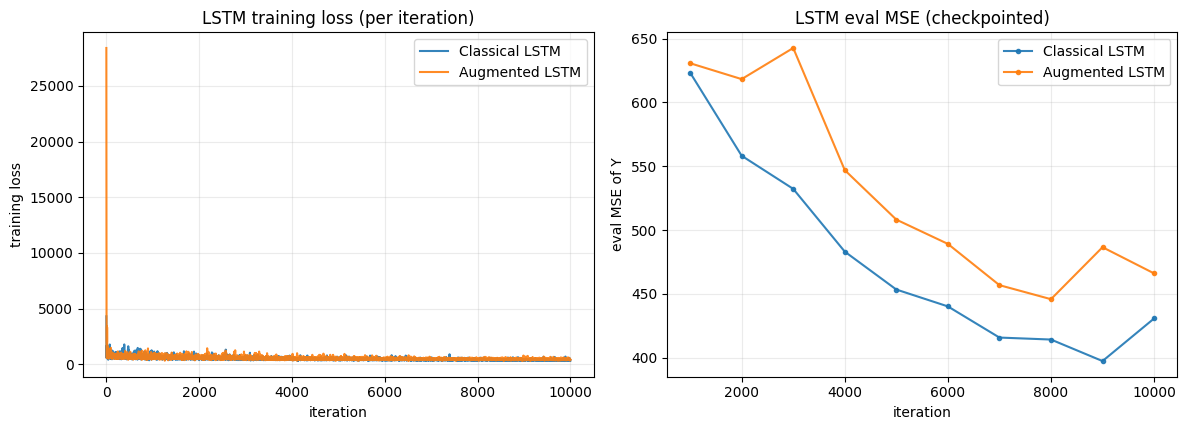

  BATES CALIBRATED A2A: COMMON EVAL PATHS
  Experiment              Model                        Our MSE     Paper MSE       Ratio
--------------------------------------------------------------------------------------
  Bates calibrated test (A2A)  BS delta benchmark         2.098e+01             —           —
  Bates calibrated test (A2A)  Bates delta (MC FD) benchmark     4.375e+01             —           —
  Bates calibrated test (A2A)  Classical LSTM             3.973e+02             —           —
  Bates calibrated test (A2A)  Augmented LSTM             4.458e+02             —           —


In [17]:
QUICK = False
if QUICK:
    N_ITER = 1200
    N_TRAIN = 25000
    N_EVAL = 10000
    N_NORM = 10000
else:
    N_ITER = 10000
    N_TRAIN = 80000
    N_EVAL = 30000
    N_NORM = 30000

BATCH = 50
LR = 1e-3


def make_bates_paths():
    tr = simulate_bates_paths_torch(N_TRAIN, spot, T_HEDGE, N_HEDGE, kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ, seed=101, device='cpu').unsqueeze(-1)
    ev = simulate_bates_paths_torch(N_EVAL,  spot, T_HEDGE, N_HEDGE, kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ, seed=102, device='cpu').unsqueeze(-1)
    rf = simulate_bates_paths_torch(N_NORM,  spot, T_HEDGE, N_HEDGE, kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ, seed=999, device='cpu').unsqueeze(-1)
    mean, std = compute_norm_stats(rf)
    return tr, ev, mean, std

cfg_bates = Config(
    name='Bates SPY call',
    d=1,
    N=N_HEDGE,
    paths_factory=make_bates_paths,
    payoff_fn=lambda p: call_payoff(p[:, -1, 0], K=K_ATM),
    arch_factory={
        'Classical LSTM': lambda: ClassicalLSTM(N=N_HEDGE, d=1, hidden=50),
        'Augmented LSTM': lambda: AugmentedLSTM(N=N_HEDGE, d=1, hidden=50, ff_width=10, ff_layers=3),
    },
    n_iter=N_ITER,
    batch_size=BATCH,
    lr=LR,
    paper_values={},
)

# Quick logic/preflight check before expensive training (small sample).
tr_chk = simulate_bates_paths_torch(256, spot, T_HEDGE, N_HEDGE, kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ, seed=11, device='cpu').unsqueeze(-1)
ev_chk = simulate_bates_paths_torch(128, spot, T_HEDGE, N_HEDGE, kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ, seed=12, device='cpu').unsqueeze(-1)
rf_chk = simulate_bates_paths_torch(128, spot, T_HEDGE, N_HEDGE, kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ, seed=13, device='cpu').unsqueeze(-1)
mean_chk, std_chk = compute_norm_stats(rf_chk)
assert tr_chk.shape[1] == N_HEDGE + 1 and tr_chk.shape[-1] == 1, f'Unexpected train shape: {tr_chk.shape}'
assert ev_chk.shape[1] == N_HEDGE + 1 and ev_chk.shape[-1] == 1, f'Unexpected eval shape: {ev_chk.shape}'
assert torch.isfinite(mean_chk).all() and torch.isfinite(std_chk).all(), 'Normalization stats contain non-finite values'
assert float(std_chk.min()) > 0.0, 'Normalization std has non-positive values'
print(f'[Preflight] OK | train={tuple(tr_chk.shape)} eval={tuple(ev_chk.shape)}')

print(f'N={N_HEDGE}, iter={N_ITER}, train/eval/norm={N_TRAIN}/{N_EVAL}/{N_NORM}')
res_bates = run_experiment(cfg_bates, device=DEVICE)

# Plot training curves (batch train loss + periodic eval MSE) for each LSTM model.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for model_name, hist in res_bates['histories'].items():
    axes[0].plot(hist['train'], label=model_name, alpha=0.9)
    axes[1].plot(hist['test_iters'], hist['test'], marker='o', ms=3, label=model_name, alpha=0.9)

axes[0].set_title('LSTM training loss (per iteration)')
axes[0].set_xlabel('iteration')
axes[0].set_ylabel('training loss')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].set_title('LSTM eval MSE (checkpointed)')
axes[1].set_xlabel('iteration')
axes[1].set_ylabel('eval MSE of Y')
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

# Apples-to-apples benchmarking: compute BS and Bates-FD on the exact same eval paths as NN.
paths_eval_common = res_bates['paths']['eval_raw'][:, :, 0].detach().cpu().numpy()
n_steps_common = paths_eval_common.shape[1] - 1
dt_common = T_HEDGE / max(n_steps_common, 1)

p0_common = bs_call_price(spot, K_ATM, T_HEDGE, sigma_bs)
S0_common = paths_eval_common[:, 0]
d_prev_common = bs_delta_np(S0_common, K_ATM, T_HEDGE, sigma_bs)
cash_common = np.full(paths_eval_common.shape[0], p0_common) - d_prev_common * S0_common
for t in range(1, n_steps_common + 1):
    tau = max(T_HEDGE - t * dt_common, 0.0)
    St = paths_eval_common[:, t]
    d_new_common = bs_delta_np(St, K_ATM, tau, sigma_bs) if t < n_steps_common else np.zeros_like(St)
    cash_common -= (d_new_common - d_prev_common) * St
    d_prev_common = d_new_common
payoff_common = np.maximum(paths_eval_common[:, -1] - K_ATM, 0.0)
portfolio_T_common = cash_common + d_prev_common * paths_eval_common[:, -1]
Y_bs_common = portfolio_T_common - payoff_common
mse_bs_common = float(np.mean(Y_bs_common ** 2))

BATES_BENCH_EVAL_COMMON = min(4000, paths_eval_common.shape[0])
paths_ba_common = paths_eval_common[:BATES_BENCH_EVAL_COMMON]

p0_ba_common = bates_call_price_mc(
    S0=float(spot),
    K=float(K_ATM),
    T=float(T_HEDGE),
    kappa=kappa,
    theta=theta,
    xi=xi,
    rho=rho,
    v0=v0,
    lambdaJ=lambdaJ,
    muJ=muJ,
    sigmaJ=sigmaJ,
    n_steps=max(6, int(round(365 * T_HEDGE))),
    n_paths=3500,
    r=0.04,
    seed=701,
)

d_prev_ba_common = bates_delta_mc_fd_vec_spots(
    paths_ba_common[:, 0],
    K_ATM,
    T_HEDGE,
    kappa=kappa,
    theta=theta,
    xi=xi,
    rho=rho,
    v0=v0,
    lambdaJ=lambdaJ,
    muJ=muJ,
    sigmaJ=sigmaJ,
    r=0.04,
    n_paths_mc=3500,
    seed=701,
)

cash_ba_common = np.full(paths_ba_common.shape[0], p0_ba_common) - d_prev_ba_common * paths_ba_common[:, 0]
for t in range(1, n_steps_common + 1):
    tau = max(T_HEDGE - t * dt_common, 0.0)
    St = paths_ba_common[:, t]
    if t < n_steps_common:
        d_new_ba_common = bates_delta_mc_fd_vec_spots(
            St,
            K_ATM,
            tau,
            kappa=kappa,
            theta=theta,
            xi=xi,
            rho=rho,
            v0=v0,
            lambdaJ=lambdaJ,
            muJ=muJ,
            sigmaJ=sigmaJ,
            r=0.04,
            n_paths_mc=3000,
            seed=701 + t,
        )
    else:
        d_new_ba_common = np.zeros_like(St)
    cash_ba_common -= (d_new_ba_common - d_prev_ba_common) * St
    d_prev_ba_common = d_new_ba_common
payoff_ba_common = np.maximum(paths_ba_common[:, -1] - K_ATM, 0.0)
portfolio_T_ba_common = cash_ba_common + d_prev_ba_common * paths_ba_common[:, -1]
Y_ba_common = portfolio_T_ba_common - payoff_ba_common
mse_bates_fd_common = float(np.mean(Y_ba_common ** 2))

mock_cfg = type('Cfg', (), {'paper_values': {}})()
comparison = {
    'Bates calibrated test (A2A)': {
        'cfg': mock_cfg,
        'mse': {
            'BS delta benchmark': mse_bs_common,
            'Bates delta (MC FD) benchmark': mse_bates_fd_common,
            'Classical LSTM': float(res_bates['mse']['Classical LSTM']),
            'Augmented LSTM': float(res_bates['mse']['Augmented LSTM']),
        }
    }
}

report_table(comparison, title='BATES CALIBRATED A2A: COMMON EVAL PATHS')

## 5b) Hyperparameter check (alternative LSTM run)

Run an additional Section 5 experiment with a different optimization setup and compare against the baseline Section 5 result.

In [ ]:
# Alternative training setup to test whether Section 5 NN MSE improves.
# Tip: this is an extra full training run; reduce ALT_N_ITER if runtime is too high.

RUN_ALT_TUNING = True

ALT_N_ITER = 20000
ALT_BATCH = 64
ALT_LR = 5e-4
ALT_TEST_EVERY = 1000

if RUN_ALT_TUNING:
    cfg_bates_alt = Config(
        name='Bates SPY call (alt hp)',
        d=1,
        N=N_HEDGE,
        paths_factory=make_bates_paths,
        payoff_fn=lambda p: call_payoff(p[:, -1, 0], K=K_ATM),
        arch_factory={
            'Classical LSTM': lambda: ClassicalLSTM(N=N_HEDGE, d=1, hidden=100),
            'Augmented LSTM': lambda: AugmentedLSTM(N=N_HEDGE, d=1, hidden=100, ff_width=20, ff_layers=3),
        },
        n_iter=ALT_N_ITER,
        batch_size=ALT_BATCH,
        lr=ALT_LR,
        test_every=ALT_TEST_EVERY,
        paper_values={},
    )

    print(
        f"[Alt run] iter={ALT_N_ITER}, batch={ALT_BATCH}, lr={ALT_LR}, "
        f"hidden=100, ff_width=20"
    )
    res_bates_alt = run_experiment(cfg_bates_alt, device=DEVICE)

    mock_cfg = type('Cfg', (), {'paper_values': {}})()
    comp_alt = {
        'Bates calibrated test (A2A)': {
            'cfg': mock_cfg,
            'mse': {
                'Baseline Classical LSTM': float(res_bates['mse']['Classical LSTM']),
                'Baseline Augmented LSTM': float(res_bates['mse']['Augmented LSTM']),
                'Alt Classical LSTM': float(res_bates_alt['mse']['Classical LSTM']),
                'Alt Augmented LSTM': float(res_bates_alt['mse']['Augmented LSTM']),
            },
        }
    }
    report_table(comp_alt, title='SECTION 5 NN HYPERPARAM CHECK (BASELINE VS ALT)')

    fig, ax = plt.subplots(1, 1, figsize=(9.5, 4.2))

    h0c = res_bates['histories']['Classical LSTM']
    h0a = res_bates['histories']['Augmented LSTM']
    h1c = res_bates_alt['histories']['Classical LSTM']
    h1a = res_bates_alt['histories']['Augmented LSTM']

    ax.plot(h0c['test_iters'], h0c['test'], 'o-', ms=3, alpha=0.9, label='Baseline Classical')
    ax.plot(h0a['test_iters'], h0a['test'], 'o-', ms=3, alpha=0.9, label='Baseline Augmented')
    ax.plot(h1c['test_iters'], h1c['test'], 's--', ms=3, alpha=0.9, label='Alt Classical')
    ax.plot(h1a['test_iters'], h1a['test'], 's--', ms=3, alpha=0.9, label='Alt Augmented')

    ax.set_title('Section 5 eval MSE curves: baseline vs alt setup')
    ax.set_xlabel('iteration')
    ax.set_ylabel('eval MSE of Y')
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('RUN_ALT_TUNING=False -> skipped alt hyperparameter run.')

In [18]:
OUT = os.path.join(ROOT, 'results_bates')
os.makedirs(OUT, exist_ok=True)
summary = {
    'meta': {
        'timestamp_utc': datetime.now(timezone.utc).isoformat(),
        'valuation_date_shifted_utc': pd.Timestamp(now).isoformat(),
        'spot': float(spot),
        'calibration_expiries': selected_expiries,
        'hedge_expiry': hedge_expiry,
        'T_hedge_years': float(T_HEDGE),
        'K_atm': float(K_ATM),
        'N_hedge': int(N_HEDGE),
        'N_hedge_target_min': int(N_HEDGE_TARGET),
        'device': DEVICE,
    },
    'bates_params': {
        'kappa': float(kappa),
        'theta': float(theta),
        'xi': float(xi),
        'rho': float(rho),
        'v0': float(v0),
        'lambdaJ': float(lambdaJ),
        'muJ': float(muJ),
        'sigmaJ': float(sigmaJ),
    },
    'calibration': {
        'objective': float(calibration_objective),
        'surface_mse': float(fit_mse),
        'n_quotes': int(len(quotes)),
    },
    'hedging_mse': {
        'BS delta benchmark (common eval paths)': float(mse_bs_common),
        'Bates delta (MC FD) benchmark (common eval paths)': float(mse_bates_fd_common),
        'Classical LSTM': float(res_bates['mse']['Classical LSTM']),
        'Augmented LSTM': float(res_bates['mse']['Augmented LSTM']),
    },
}
sp = os.path.join(OUT, 'bates_spy_summary.json')
with open(sp, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)
print('Saved:', sp)

Saved: c:\Users\Michael\Code\ML-for-Finance\results_bates\bates_spy_summary.json


## 6) Paper-style liquidity + transaction-cost Pareto training (Eq. 22)

We now follow Section 7 of the paper in the Bates market:

- fixed premium `p = E[g(S_T)]` (not optimized),
- proportional transaction costs `c` per traded unit,
- liquidity cap `liq` on per-step position change,
- one **Augmented LSTM** trained for all `alpha in [0,1]` by adding `alpha` to inputs,
- `alpha` sampled with a Sobol quasi-random generator each iteration.

Objective (paper Eq. 22):

`d_alpha = (1-alpha) E[TC] + alpha * sqrt(E[(X_T - g(S_T))^2])`

Premium fixed at E[g(S_T)] = 22.8363
iter    500/5000 | loss=2.5313e+00 | alpha~0.160
iter   1000/5000 | loss=6.3492e+00 | alpha~0.486
iter   1500/5000 | loss=6.2357e-01 | alpha~0.054
iter   2000/5000 | loss=2.5011e+00 | alpha~0.350
iter   2500/5000 | loss=1.9629e+00 | alpha~0.227
iter   3000/5000 | loss=2.3346e+00 | alpha~0.403
iter   3500/5000 | loss=5.0642e-01 | alpha~0.101
iter   4000/5000 | loss=1.2089e+00 | alpha~0.258
iter   4500/5000 | loss=5.7923e-01 | alpha~0.132
iter   5000/5000 | loss=2.7758e+00 | alpha~0.461


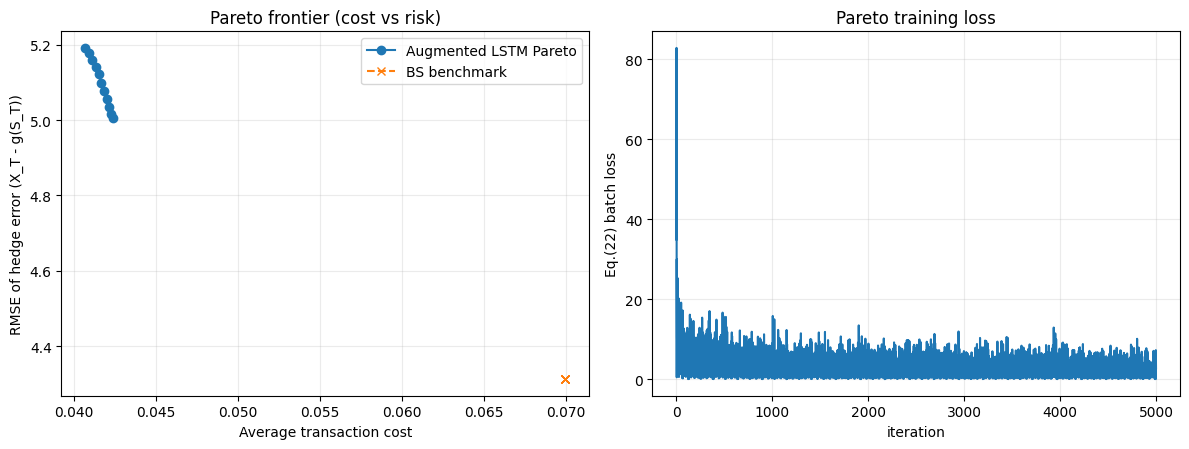

Saved: c:\Users\Michael\Code\ML-for-Finance\results_bates\bates_pareto_frontier.json


In [19]:
from torch.quasirandom import SobolEngine

# --- configuration (paper-style but reduced for notebook runtime) ---
PARETO_ITERS = 5000          # paper uses 100k; increase if you want a tighter frontier
PARETO_BATCH = 64
PARETO_LR = 1e-3
PARETO_HIDDEN = 50
PARETO_FF_WIDTH = 50         # paper section 7 increases projection width to 50
PARETO_FF_LAYERS = 3

N_TRAIN_P = 70000
N_EVAL_P = 30000
N_NORM_P = 30000

TC_PER_UNIT = 0.02           # paper-style constant c_j
LIQ = 0.35                   # max per-step delta change (model units)

# --- build Bates datasets for Pareto run ---
train_raw = simulate_bates_paths_torch(
    N_TRAIN_P, spot, T_HEDGE, N_HEDGE,
    kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ,
    seed=310, device=DEVICE
).unsqueeze(-1)

eval_raw = simulate_bates_paths_torch(
    N_EVAL_P, spot, T_HEDGE, N_HEDGE,
    kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ,
    seed=311, device=DEVICE
).unsqueeze(-1)

ref_raw = simulate_bates_paths_torch(
    N_NORM_P, spot, T_HEDGE, N_HEDGE,
    kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ,
    seed=399, device=DEVICE
).unsqueeze(-1)

norm_mean, norm_std = compute_norm_stats(ref_raw)
train_norm = (train_raw - norm_mean) / norm_std
eval_norm = (eval_raw - norm_mean) / norm_std

# Fixed premium p = E[g(S_T)] on train set (paper section 7)
with torch.no_grad():
    payoff_train = call_payoff(train_raw[:, -1, 0], K=K_ATM)
    premium_fixed = float(payoff_train.mean().item())

print(f'Premium fixed at E[g(S_T)] = {premium_fixed:.4f}')

# Model with alpha as extra input (extra_in=1)
pareto_model = AugmentedLSTM(
    N=N_HEDGE, d=1, hidden=PARETO_HIDDEN,
    ff_width=PARETO_FF_WIDTH, ff_layers=PARETO_FF_LAYERS,
    extra_in=1,
).to(DEVICE)

# freeze premium at p and do not optimize it
with torch.no_grad():
    pareto_model.premium.fill_(premium_fixed)
pareto_model.premium.requires_grad_(False)

optimizer = torch.optim.Adam(
    [p for p in pareto_model.parameters() if p.requires_grad],
    lr=PARETO_LR,
)

sobol = SobolEngine(dimension=1, scramble=True, seed=2026)

train_hist = []
for it in range(PARETO_ITERS):
    idx = torch.randint(0, train_raw.shape[0], (PARETO_BATCH,), device=DEVICE)
    br = train_raw[idx]
    bn = train_norm[idx]

    alpha = sobol.draw(1).to(DEVICE).view(1).expand(PARETO_BATCH)

    out = pareto_model(br, bn, liq=LIQ, alpha=alpha, tc_cost=TC_PER_UNIT)
    g = call_payoff(br[:, -1, 0], K=K_ATM)

    # X_T and transaction costs for Eq. (22)
    X = out['pnl']
    tc = out['tc']
    err = X - g

    a = alpha.mean()
    loss = (1.0 - a) * tc.mean() + a * torch.sqrt((err ** 2).mean() + 1e-12)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(pareto_model.parameters(), 1.0)
    optimizer.step()

    train_hist.append(float(loss.item()))
    if (it + 1) % 500 == 0:
        print(f'iter {it+1:>6d}/{PARETO_ITERS} | loss={train_hist[-1]:.4e} | alpha~{float(a):.3f}')

# --- evaluate frontier for fixed alpha grid ---
def eval_pareto_point(model, alpha_value: float):
    with torch.no_grad():
        a = torch.full((eval_raw.shape[0],), float(alpha_value), device=DEVICE)
        out = model(eval_raw, eval_norm, liq=LIQ, alpha=a, tc_cost=TC_PER_UNIT)
        g = call_payoff(eval_raw[:, -1, 0], K=K_ATM)
        X = out['pnl']
        tc = out['tc']
        err = X - g
        rmse = torch.sqrt((err ** 2).mean())
        d_alpha = (1.0 - alpha_value) * tc.mean() + alpha_value * rmse
        Y = X - g - tc
        mseY = (Y ** 2).mean()
    return {
        'alpha': float(alpha_value),
        'mean_tc': float(tc.mean().item()),
        'rmse_err': float(rmse.item()),
        'criterion': float(d_alpha.item()),
        'mse_Y': float(mseY.item()),
    }

frontier = [eval_pareto_point(pareto_model, a) for a in np.linspace(0.0, 1.0, 11)]

# BS baseline under same liq+tc for comparison at each alpha
def bs_frontier_point(alpha_value: float):
    # Liquidity-capped BS delta rebalancing on the same eval paths
    P = eval_raw[:, :, 0].detach().cpu().numpy()
    n_paths = P.shape[0]
    n_steps = P.shape[1] - 1
    dt = T_HEDGE / n_steps

    # same fixed premium as in Pareto setup
    cash = np.full(n_paths, premium_fixed, dtype=float)
    delta_prev = np.zeros(n_paths, dtype=float)
    tc_paid = np.zeros(n_paths, dtype=float)

    for t in range(n_steps):
        tau = max(T_HEDGE - t * dt, 1e-8)
        St = P[:, t]
        d_target = bs_delta_np(St, K_ATM, tau, sigma_bs)
        # enforce liquidity cap on delta change
        d_new = delta_prev + np.clip(d_target - delta_prev, -LIQ, LIQ)
        trade = d_new - delta_prev
        tc_paid += TC_PER_UNIT * np.abs(trade)

        dS = P[:, t + 1] - St
        cash += d_new * dS
        delta_prev = d_new

    payoff = np.maximum(P[:, -1] - K_ATM, 0.0)
    X = cash
    err = X - payoff
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mean_tc = float(np.mean(tc_paid))
    d_alpha = (1.0 - alpha_value) * mean_tc + alpha_value * rmse
    Y = X - payoff - tc_paid
    mseY = float(np.mean(Y ** 2))

    return {
        'alpha': float(alpha_value),
        'mean_tc': mean_tc,
        'rmse_err': rmse,
        'criterion': float(d_alpha),
        'mse_Y': mseY,
    }

bs_frontier = [bs_frontier_point(a) for a in np.linspace(0.0, 1.0, 11)]

# --- plots ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))

ax[0].plot([p['mean_tc'] for p in frontier], [p['rmse_err'] for p in frontier], 'o-', label='Augmented LSTM Pareto')
ax[0].plot([p['mean_tc'] for p in bs_frontier], [p['rmse_err'] for p in bs_frontier], 'x--', label='BS benchmark')
ax[0].set_xlabel('Average transaction cost')
ax[0].set_ylabel('RMSE of hedge error (X_T - g(S_T))')
ax[0].set_title('Pareto frontier (cost vs risk)')
ax[0].grid(alpha=0.25)
ax[0].legend()

ax[1].plot(train_hist)
ax[1].set_title('Pareto training loss')
ax[1].set_xlabel('iteration')
ax[1].set_ylabel('Eq.(22) batch loss')
ax[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# --- save ---
out = {
    'meta': {
        'model': 'AugmentedLSTM Pareto (Bates)',
        'premium_fixed': premium_fixed,
        'tc_per_unit': TC_PER_UNIT,
        'liq': LIQ,
        'n_iter': PARETO_ITERS,
        'n_train': N_TRAIN_P,
        'n_eval': N_EVAL_P,
    },
    'frontier_nn': frontier,
    'frontier_bs': bs_frontier,
}
os.makedirs(os.path.join(ROOT, 'results_bates'), exist_ok=True)
fp = os.path.join(ROOT, 'results_bates', 'bates_pareto_frontier.json')
with open(fp, 'w', encoding='utf-8') as f:
    json.dump(out, f, indent=2)
print('Saved:', fp)

## 7) Backtest on actual SPY option time series (BS vs Bates vs NN)

This section evaluates one-step hedging on a real option contract history:

- **BS delta** using calibrated `sigma_bs`,
- **Bates delta** from finite-difference Monte Carlo pricing,
- **Classical / Augmented LSTM** deltas from the trained Bates models.

Metric: MSE of daily residuals `dC - Delta * dS` on the realized time series.

Backtest contract: SPY260630C00660000 | K=660.00 | expiry=2026-06-30

Realized one-step hedge residuals on actual SPY option series (WITH TC + LIQ):
             method  mse_resid  mean_resid  std_resid  avg_tc_per_step  n_steps_used  tc_per_unit  liq_step_cap
           BS delta 2.0098e+00 -1.0597e-01 1.4137e+00       6.8578e-04            90   2.0000e-02    3.5000e-01
     Classical LSTM 2.5430e+00 -6.8227e-02 1.5932e+00       5.5292e-04            90   2.0000e-02    3.5000e-01
     Augmented LSTM 2.6676e+00  9.1633e-04 1.6333e+00       5.3205e-04            90   2.0000e-02    3.5000e-01
Bates delta (MC FD) 7.6627e+00 -2.3869e-01 2.7578e+00       1.3170e-03            90   2.0000e-02    3.5000e-01


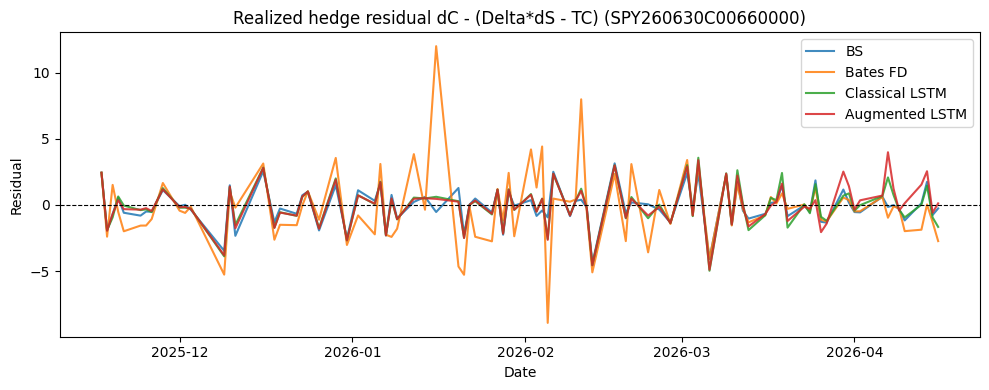

Saved: c:\Users\Michael\Code\ML-for-Finance\results_bates\bates_real_timeseries_backtest_with_tc.csv


In [21]:
# --- 7) Backtest on actual SPY option time series (BS vs Bates vs NN) WITH TC + LIQ ---

if "res_bates" not in globals():
    raise RuntimeError("Run Section 5 first so res_bates models are available.")

# Backtest frictions (set to match your Section 6 if desired)
TC_BT = float(TC_PER_UNIT) if "TC_PER_UNIT" in globals() else 0.02
LIQ_BT = float(LIQ) if "LIQ" in globals() else 0.2  # max abs delta change per step

def bs_delta_np_vec(S, K, T, sigma):
    S = np.asarray(S, dtype=float)
    T = np.asarray(T, dtype=float)
    S, T = np.broadcast_arrays(S, T)

    sigma_arr = np.asarray(sigma, dtype=float)
    if sigma_arr.ndim == 0:
        sigma_arr = np.full_like(S, float(sigma_arr))
    else:
        sigma_arr = np.broadcast_to(sigma_arr, S.shape)

    out = np.empty_like(S, dtype=float)
    bad = (T <= 0.0) | (sigma_arr <= 0.0)
    out[bad] = np.where(S[bad] > K, 1.0, 0.0)

    good = ~bad
    if np.any(good):
        d1 = (np.log(S[good] / K) + 0.5 * sigma_arr[good] ** 2 * T[good]) / (
            sigma_arr[good] * np.sqrt(T[good])
        )
        out[good] = 0.5 * (1.0 + np.vectorize(math.erf)(d1 / np.sqrt(2.0)))
    return out

def bates_delta_mc(S0, K, T, eps_rel=1e-3, n_paths=12000):
    eps = max(0.05, eps_rel * S0)
    p_up = bates_call_prices_mc(
        S0=S0 + eps,
        K_array=np.array([K]),
        T=float(T),
        params=(kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ),
        n_steps=max(6, int(round(365 * T))),
        n_paths=n_paths,
        seed=1234,
    )[0]
    p_dn = bates_call_prices_mc(
        S0=S0 - eps,
        K_array=np.array([K]),
        T=float(T),
        params=(kappa, theta, xi, rho, v0, lambdaJ, muJ, sigmaJ),
        n_steps=max(6, int(round(365 * T))),
        n_paths=n_paths,
        seed=1235,
    )[0]
    return float((p_up - p_dn) / (2 * eps))

# Execution friction helper imported from src.bates:
# apply_friction_to_deltas

# Local ticker handle for this section (works whether snapshot was loaded from cache or refreshed).
if yf is None:
    raise RuntimeError("yfinance is required for real-series backtest in Section 7.")
tk = yf.Ticker("SPY")

# --------- pick maturity + near-ATM option ----------
chain_h = tk.option_chain(hedge_expiry).calls.copy()
chain_h = chain_h[(chain_h["bid"] > 0) & (chain_h["ask"] > 0) & (chain_h["strike"] > 0)].copy()
if chain_h.empty:
    raise RuntimeError("No valid calls in hedge expiry chain.")

chain_h["mny_dist"] = np.abs(chain_h["strike"] / spot - 1.0)
row = chain_h.sort_values(["mny_dist", "ask"]).iloc[0]
contract_symbol = row["contractSymbol"]
K_backtest = float(row["strike"])
print(f"Backtest contract: {contract_symbol} | K={K_backtest:.2f} | expiry={hedge_expiry}")

# --------- realized histories ----------
opt_hist = yf.Ticker(contract_symbol).history(period="6mo", interval="1d", auto_adjust=False)[["Close"]].copy()
und_hist = tk.history(period="1y", interval="1d", auto_adjust=False)[["Close"]].copy()
if opt_hist.empty or und_hist.empty:
    raise RuntimeError("Failed to load option/underlying history for backtest.")

opt_hist.index = pd.to_datetime(opt_hist.index).tz_localize(None)
und_hist.index = pd.to_datetime(und_hist.index).tz_localize(None)

bt = (
    opt_hist.rename(columns={"Close": "C"})
    .join(und_hist.rename(columns={"Close": "S"}), how="inner")
    .dropna()
)

bt = bt.loc[bt.index <= pd.Timestamp(hedge_expiry)].copy()

available_steps = bt.shape[0] - 1
if available_steps < 5:
    raise RuntimeError(f"Too few joined rows ({bt.shape[0]}). Need at least 6 rows.")

N_BT = min(int(N_HEDGE), int(available_steps))
if N_BT < N_HEDGE:
    print(f"[Info] Using shorter backtest horizon N_BT={N_BT} (requested N_HEDGE={N_HEDGE}).")

bt = bt.iloc[-(N_BT + 1):].copy()
bt["S_next"] = bt["S"].shift(-1)
bt["C_next"] = bt["C"].shift(-1)
bt = bt.dropna().copy()

S = bt["S"].to_numpy(dtype=float)
S_next = bt["S_next"].to_numpy(dtype=float)
C = bt["C"].to_numpy(dtype=float)
C_next = bt["C_next"].to_numpy(dtype=float)

dS = S_next - S
dC = C_next - C

exp_ts = pd.Timestamp(hedge_expiry)
tau = np.maximum((exp_ts - bt.index).days.to_numpy(dtype=float) / 365.0, 1 / 365)

# --------- target deltas (frictionless signals) ----------
delta_bs_tgt = bs_delta_np_vec(S, K_backtest, tau, sigma_bs)
delta_bates_tgt = np.array([bates_delta_mc(s0, K_backtest, t) for s0, t in zip(S, tau)], dtype=float)

# NN target deltas (pad to training horizon)
path_real = np.concatenate([S, [S_next[-1]]]).astype(np.float32)
L_real = path_real.shape[0]
L_train = int(N_HEDGE) + 1

if L_real < L_train:
    pad = np.full((L_train - L_real,), path_real[-1], dtype=np.float32)
    path_in = np.concatenate([path_real, pad], axis=0)
else:
    path_in = path_real[-L_train:]

raw_t = torch.from_numpy(path_in[None, :, None]).to(DEVICE)

mean_nn = res_bates["paths"]["norm_mean"]
std_nn = res_bates["paths"]["norm_std"]
if mean_nn.device != raw_t.device:
    mean_nn = mean_nn.to(raw_t.device)
    std_nn = std_nn.to(raw_t.device)

norm_t = (raw_t - mean_nn) / std_nn

with torch.no_grad():
    o_c = res_bates["models"]["Classical LSTM"](raw_t, norm_t, liq=float("inf"), tc_cost=None)
    o_a = res_bates["models"]["Augmented LSTM"](raw_t, norm_t, liq=float("inf"), tc_cost=None)

delta_cls_tgt_full = o_c["delta"][0, :, 0].detach().cpu().numpy()
delta_aug_tgt_full = o_a["delta"][0, :, 0].detach().cpu().numpy()

n_real_steps = len(dS)
delta_cls_tgt = delta_cls_tgt_full[:n_real_steps]
delta_aug_tgt = delta_aug_tgt_full[:n_real_steps]

# --------- apply same execution frictions to all methods ----------
delta_bs_exec, hedge_bs_inc, tc_bs = apply_friction_to_deltas(delta_bs_tgt, dS, TC_BT, LIQ_BT)
delta_ba_exec, hedge_ba_inc, tc_ba = apply_friction_to_deltas(delta_bates_tgt, dS, TC_BT, LIQ_BT)
delta_cl_exec, hedge_cl_inc, tc_cl = apply_friction_to_deltas(delta_cls_tgt, dS, TC_BT, LIQ_BT)
delta_au_exec, hedge_au_inc, tc_au = apply_friction_to_deltas(delta_aug_tgt, dS, TC_BT, LIQ_BT)

m = min(len(dC), len(hedge_bs_inc), len(hedge_ba_inc), len(hedge_cl_inc), len(hedge_au_inc))
idx_use = bt.index[:m]
dC_use = dC[:m]

resid_bs = dC_use - hedge_bs_inc[:m]
resid_ba = dC_use - hedge_ba_inc[:m]
resid_cl = dC_use - hedge_cl_inc[:m]
resid_au = dC_use - hedge_au_inc[:m]

summary_bt = pd.DataFrame(
    {
        "method": ["BS delta", "Bates delta (MC FD)", "Classical LSTM", "Augmented LSTM"],
        "mse_resid": [
            float(np.mean(resid_bs**2)),
            float(np.mean(resid_ba**2)),
            float(np.mean(resid_cl**2)),
            float(np.mean(resid_au**2)),
        ],
        "mean_resid": [
            float(np.mean(resid_bs)),
            float(np.mean(resid_ba)),
            float(np.mean(resid_cl)),
            float(np.mean(resid_au)),
        ],
        "std_resid": [
            float(np.std(resid_bs)),
            float(np.std(resid_ba)),
            float(np.std(resid_cl)),
            float(np.std(resid_au)),
        ],
        "avg_tc_per_step": [
            float(np.mean(tc_bs[:m])),
            float(np.mean(tc_ba[:m])),
            float(np.mean(tc_cl[:m])),
            float(np.mean(tc_au[:m])),
        ],
        "n_steps_used": [int(m)] * 4,
        "tc_per_unit": [TC_BT] * 4,
        "liq_step_cap": [LIQ_BT] * 4,
    }
).sort_values("mse_resid")

print("\nRealized one-step hedge residuals on actual SPY option series (WITH TC + LIQ):")
print(summary_bt.to_string(index=False, float_format=lambda x: f"{x:.4e}"))

plt.figure(figsize=(10, 4))
plt.plot(idx_use, resid_bs, label="BS", alpha=0.85)
plt.plot(idx_use, resid_ba, label="Bates FD", alpha=0.85)
plt.plot(idx_use, resid_cl, label="Classical LSTM", alpha=0.85)
plt.plot(idx_use, resid_au, label="Augmented LSTM", alpha=0.85)
plt.axhline(0.0, color="k", lw=0.8, ls="--")
plt.title(f"Realized hedge residual dC - (Delta*dS - TC) ({contract_symbol})")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.tight_layout()
plt.show()

os.makedirs(os.path.join(ROOT, "results_bates"), exist_ok=True)
out_bt = os.path.join(ROOT, "results_bates", "bates_real_timeseries_backtest_with_tc.csv")
summary_bt.to_csv(out_bt, index=False)
print("Saved:", out_bt)